# Apple (AAPL) Hisse Senedi Fiyat Tahmin Projesi (PyTorch)
Bu proje, Apple Inc. (AAPL) şirketinin geçmiş hisse senedi kapanış fiyatlarını kullanarak gelecekteki fiyat trendlerini PyTorch kütüphanesi ve LSTM/GRU derin öğrenme modelleri ile tahmin etmek amacıyla geliştirilmiştir.

In [1]:
# Gerekli Kütüphaneler
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="darkgrid")


### 1. Veri Yükleme ve İnceleme

[*********************100%***********************]  1 of 1 completed

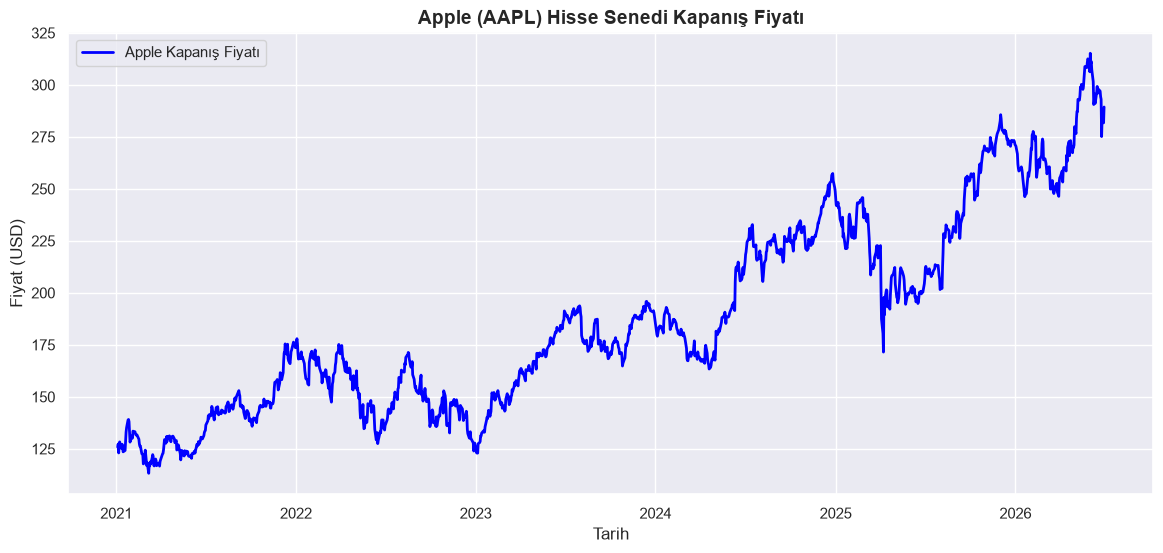

In [2]:
df = yf.download("AAPL", start="2021-01-01", end="2026-07-01")

plt.figure(figsize=(14, 6))
plt.plot(df.index, df[('Close', 'AAPL')], color='blue', linewidth=2, label='Apple Kapanış Fiyatı')
plt.title('Apple (AAPL) Hisse Senedi Kapanış Fiyatı', fontsize=14, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend()
plt.show()


### 2. Veri Ön İşleme (Data Preprocessing)

In [3]:
close_prices = df[('Close', 'AAPL')].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

seq_length = 60
X_data, y_data = [], []
for i in range(seq_length, len(scaled_data)):
    X_data.append(scaled_data[i-seq_length:i, 0])
    y_data.append(scaled_data[i, 0])

X_data, y_data = np.array(X_data), np.array(y_data)

train_size = int(len(X_data) * 0.8)
X_train, X_test = X_data[:train_size], X_data[train_size:]
y_train, y_test = y_data[:train_size], y_data[train_size:]

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)


### 3. PyTorch ile LSTM Modeli (60 Epoch)

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=50, num_layers=2, output_dim=1):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

lstm_model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

epochs = 60
print("LSTM Modeli Eğitiliyor...")
for epoch in range(epochs):
    lstm_model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = lstm_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
print("LSTM Eğitimi Tamamlandı!")


LSTM Modeli Eğitiliyor...


LSTM Eğitimi Tamamlandı!


### 4. PyTorch ile GRU Modeli (60 Epoch)

In [5]:
class GRUModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=50, num_layers=2, output_dim=1):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, hn = self.gru(x, h0.detach())
        out = self.fc(out[:, -1, :])
        return out

gru_model = GRUModel()
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.001)

print("GRU Modeli Eğitiliyor...")
for epoch in range(epochs):
    gru_model.train()
    for batch_x, batch_y in train_loader:
        optimizer_gru.zero_grad()
        outputs = gru_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_gru.step()
print("GRU Eğitimi Tamamlandı!")


GRU Modeli Eğitiliyor...


GRU Eğitimi Tamamlandı!


### 5. Modellerin Değerlendirilmesi ve Karşılaştırma

--- PyTorch LSTM Sonuçları ---
MSE: 109.95
RMSE: 10.49

--- PyTorch GRU Sonuçları ---
MSE: 37.95
RMSE: 6.16


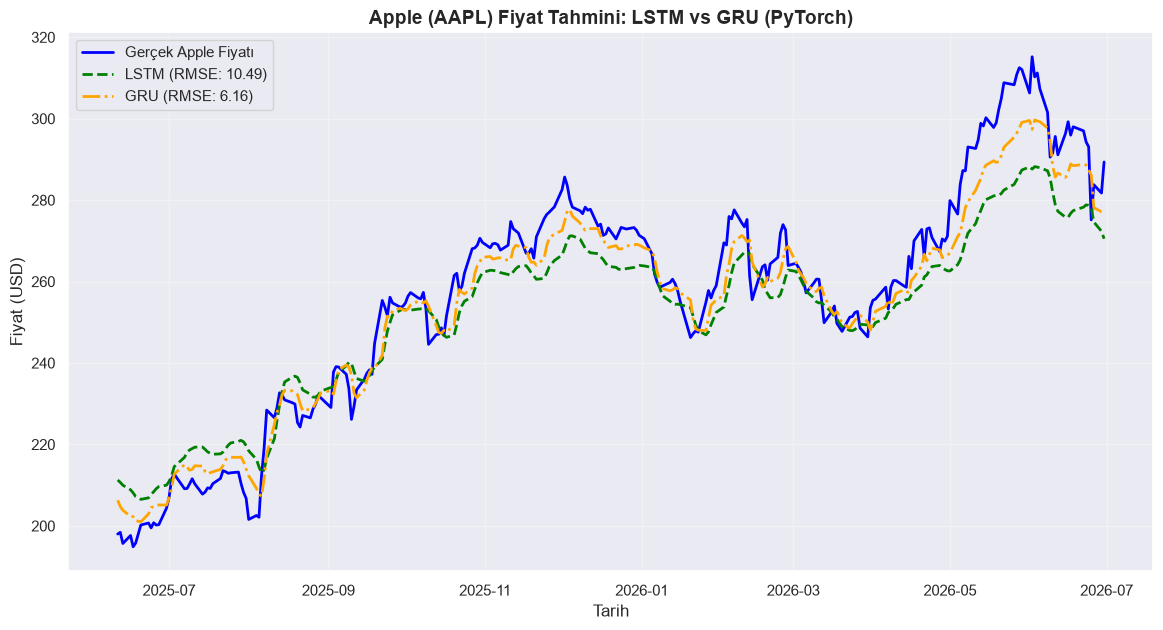

In [6]:
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds_scaled = lstm_model(X_test_t).numpy()
    gru_preds_scaled = gru_model(X_test_t).numpy()

lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
gru_preds = scaler.inverse_transform(gru_preds_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

lstm_mse = mean_squared_error(y_test_real, lstm_preds)
lstm_rmse = np.sqrt(lstm_mse)
gru_mse = mean_squared_error(y_test_real, gru_preds)
gru_rmse = np.sqrt(gru_mse)

print(f"--- PyTorch LSTM Sonuçları ---")
print(f"MSE: {lstm_mse:.2f}")
print(f"RMSE: {lstm_rmse:.2f}\n")
print(f"--- PyTorch GRU Sonuçları ---")
print(f"MSE: {gru_mse:.2f}")
print(f"RMSE: {gru_rmse:.2f}")

plt.figure(figsize=(14, 7))
test_dates = df.index[train_size + seq_length:]
plt.plot(test_dates, y_test_real, color='blue', label='Gerçek Apple Fiyatı', linewidth=2)
plt.plot(test_dates, lstm_preds, color='green', linestyle='--', label=f'LSTM (RMSE: {lstm_rmse:.2f})', linewidth=2)
plt.plot(test_dates, gru_preds, color='orange', linestyle='-.', label=f'GRU (RMSE: {gru_rmse:.2f})', linewidth=2)
plt.title('Apple (AAPL) Fiyat Tahmini: LSTM vs GRU (PyTorch)', fontsize=14, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

with open('metrics.txt', 'w') as f:
    f.write(f"{lstm_mse:.2f},{lstm_rmse:.2f},{gru_mse:.2f},{gru_rmse:.2f}")
